# LABOR-9: Bestimmung der S-Parameter S11 und S21 des 433MHz SAW Filters

### Ziel

- Mit dem Netzwerkanalysator soll S11 und S21 des 422MHz SAW Filters im Frequenzbereich 400 - 500MHz bestimmt werden.
- Nutze dafür ein Notebook aus einer früheren LAborübung!

Verwende auch das Record /Replay Prinzip, um die Messungen der S-Parameter durchzuführen und zu speichern


#


## SAW-Filter für 433MHz ISM Band

![SAW Filter](media\SAW-filter.png)

## Diverse SMA-Kupplungen und RG-174 SMA Koaxialkabel

## HIER einfügen: Foto vom Messaufbau 

![Messaufbau](media\aufbau_s11_s21.jpeg)  

In [8]:
import json
import socket
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from matplotlib.patches import Circle
from matplotlib.widgets import Slider

try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    pass

FPC_IP = "192.168.1.10"
FPC_PORT = 5555
SOCKET_TIMEOUT = 10.0
SCREENSHOT_TIMEOUT = 15.0
TRACE_READ_MAX_BYTES = 2 * 1024 * 1024

# Offline-Workflow: bei REPLAY=True werden Messdaten aus JSON geladen
REPLAY = False
REPLAY_FILE = Path("recordings") / "1-fpc1500_na_s11_replay.json"

SCREENSHOT_DIR = Path("screenshots")
SCREENSHOT_FILENAME = "screen.png"

Z0 = 50.0
SMITH_GRID_R = [0.0, 0.2, 0.5, 1.0, 2.0, 5.0]
SMITH_GRID_X = [0.2, 0.5, 1.0, 2.0, 5.0]

print(f"Konfiguration: {FPC_IP}:{FPC_PORT}")
print(f"REPLAY={REPLAY}, Datei={REPLAY_FILE}")

Konfiguration: 192.168.1.10:5555
REPLAY=False, Datei=recordings\1-fpc1500_na_s11_replay.json


In [9]:
def scpi_query(host: str, port: int, cmd: str, timeout: float = SOCKET_TIMEOUT, max_bytes: int = 4096) -> str:
    cmd = cmd.strip() + "\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(timeout)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while len(buf) < max_bytes:
            chunk = s.recv(8192)
            if not chunk:
                break
            buf += chunk
            if b"\n" in buf:
                break
        return buf.decode("utf-8", errors="replace").strip()
    finally:
        s.close()

def parse_float_list(raw: str) -> np.ndarray:
    vals = []
    for part in raw.replace(",", " ").split():
        try:
            vals.append(float(part))
        except ValueError:
            continue
    return np.asarray(vals, dtype=np.float64)

def get_freq_axis(host: str, port: int, n: int) -> np.ndarray:
    try:
        f_start = float(scpi_query(host, port, "FREQ:STAR?", max_bytes=256))
        f_stop = float(scpi_query(host, port, "FREQ:STOP?", max_bytes=256))
    except Exception:
        cent = float(scpi_query(host, port, "FREQ:CENT?", max_bytes=256))
        span = float(scpi_query(host, port, "FREQ:SPAN?", max_bytes=256))
        f_start = cent - span / 2.0
        f_stop = cent + span / 2.0
    return np.linspace(f_start, f_stop, n)

def to_mag_linear(vals: np.ndarray) -> tuple[np.ndarray, str]:
    if vals.size == 0:
        return vals, "empty"
    vmin = float(np.nanmin(vals))
    vmax = float(np.nanmax(vals))
    #if vmax <= 3.0 and vmin < -0.5:
    if True:
        return 10.0 ** (vals / 20.0), "dB->linear"
    return vals, "linear"


def save_replay_json(path: Path, data: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2), encoding="utf-8")


def load_replay_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Replay-Datei nicht gefunden: {path}")
    return json.loads(path.read_text(encoding="utf-8"))

def screenshot_save(host: str, port: int, filename: str = "screen.png") -> str | None:
    commands = ["HCOP:DEV:LANG PNG", "HCOP:DEST 'MMEM'", f"MMEM:NAME '{filename}'", "HCOP:IMM"]
    cmd = "\n".join(commands) + "\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SCREENSHOT_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        return None
    except Exception as ex:
        return str(ex)
    finally:
        s.close()

def screenshot_read(host: str, port: int, filename: str) -> bytes | None:
    cmd = f"MMEM:DATA? '{filename}'\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SCREENSHOT_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while b"#" not in buf and len(buf) < 1024:
            chunk = s.recv(256)
            if not chunk:
                return None
            buf += chunk
        if b"#" not in buf:
            return None
        start = buf.index(b"#")
        buf = buf[start:]
        while len(buf) < 2:
            buf += s.recv(2 - len(buf))
        n_digits = int(chr(buf[1]))
        while len(buf) < 2 + n_digits:
            buf += s.recv(2 + n_digits - len(buf))
        data_len = int(buf[2:2 + n_digits].decode())
        payload = buf[2 + n_digits:]
        while len(payload) < data_len:
            chunk = s.recv(min(65536, data_len - len(payload)))
            if not chunk:
                break
            payload += chunk
        return payload[:data_len] if len(payload) >= data_len else None
    except Exception:
        return None
    finally:
        s.close()

In [10]:
if REPLAY:
    replay = load_replay_json(REPLAY_FILE)
    phase_deg = np.asarray(replay["phase_deg"], dtype=float)
    freq_hz = np.asarray(replay["freq_hz"], dtype=float)
    phase_mode = replay.get("phase_mode", "deg")
    idn = replay.get("idn", "REPLAY")
    print("Replay geladen:", REPLAY_FILE)
    print("Geraet:", idn)
else:
    idn = scpi_query(FPC_IP, FPC_PORT, "*IDN?")
    print("Geraet:", idn if idn else "Keine Antwort")

    phase_raw = scpi_query(FPC_IP, FPC_PORT, "TRAC:DATA? TRACE1", max_bytes=TRACE_READ_MAX_BYTES)
    phase_trace = parse_float_list(phase_raw)
    if phase_trace.size < 2:
        raise RuntimeError("PHASE-TRACE leer. Bitte Format=PHASE am Geraet einstellen.")

    freq_hz = get_freq_axis(FPC_IP, FPC_PORT, phase_trace.size)
    phase_deg = phase_trace
    phase_mode = "deg"

print(f"PHASE gelesen: N={phase_deg.size}, mode={phase_mode}")

Geraet: Rohde&Schwarz,FPC1500,1328.6660K03/206021,V1.90
PHASE gelesen: N=201, mode=deg


Replay gespeichert: recordings\1-fpc1500_na_s11_replay.json


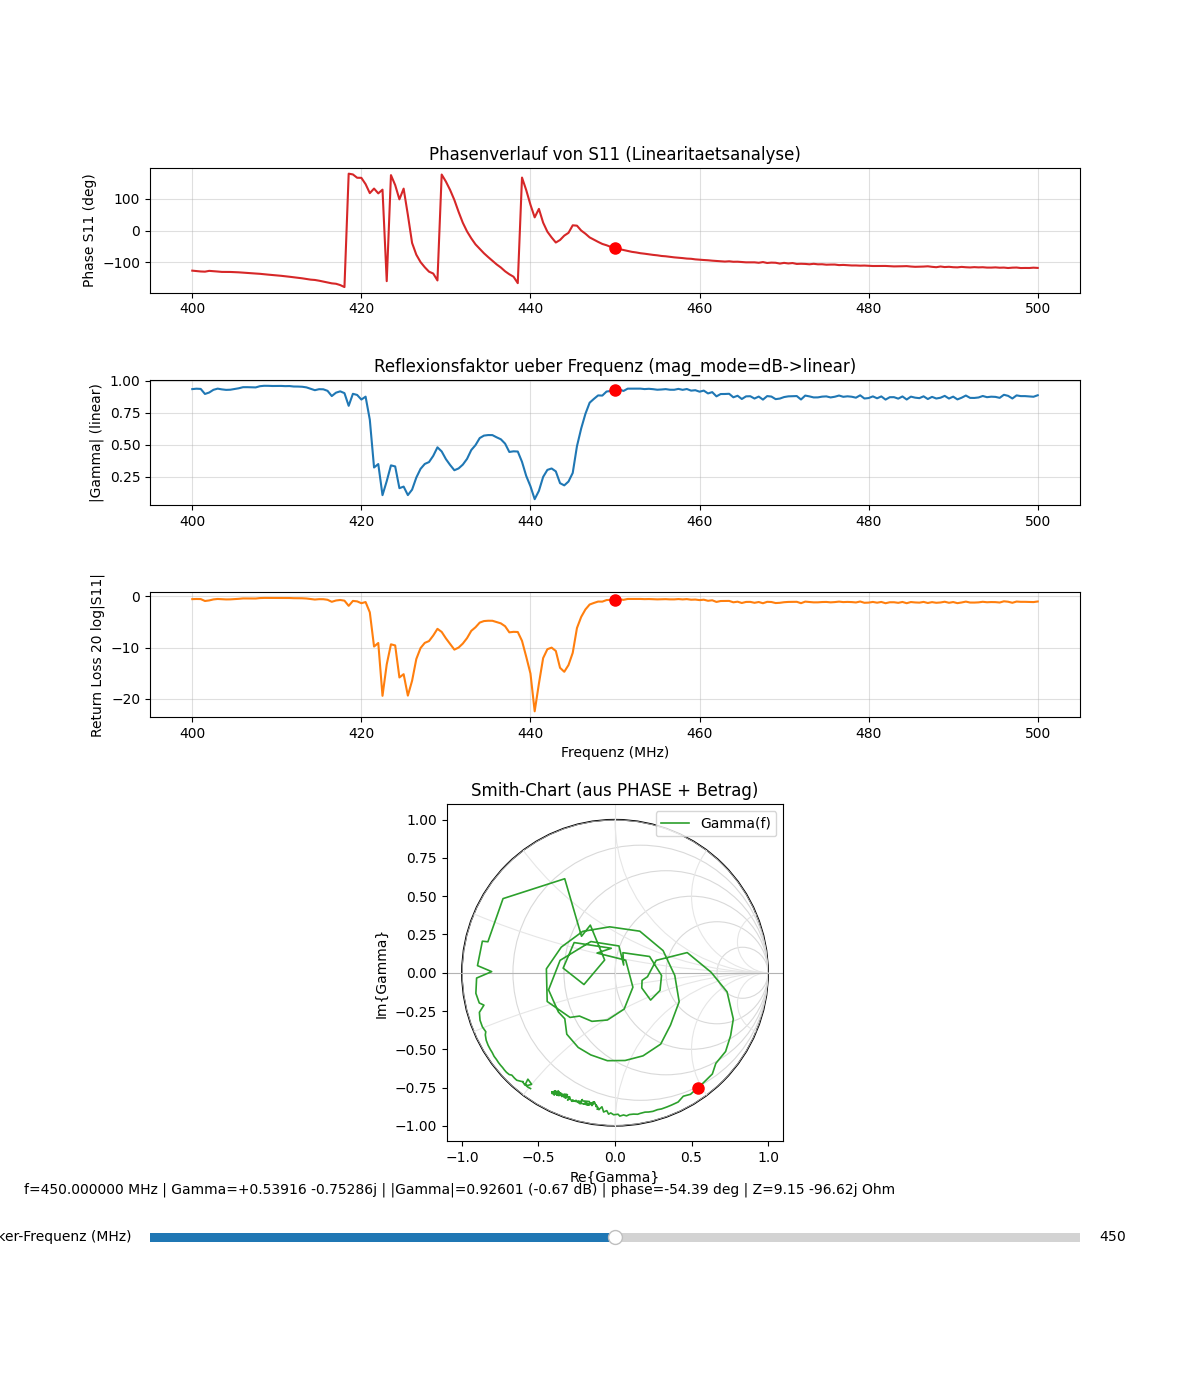

In [12]:
if "phase_deg" not in globals() or "freq_hz" not in globals():
    raise RuntimeError("Bitte zuerst die PHASE-Cell ausfuehren.")

if REPLAY:
    replay = load_replay_json(REPLAY_FILE)
    mag_trace = np.asarray(replay["mag_trace"], dtype=float)
    n = min(mag_trace.size, phase_deg.size, freq_hz.size)
    mag_trace = mag_trace[:n]
    phase_deg = phase_deg[:n]
    freq_hz = freq_hz[:n]
    mag_mode = replay.get("mag_mode", "replay")
    print("Replay-Magnitude geladen:", REPLAY_FILE)
else:
    mag_raw = scpi_query(FPC_IP, FPC_PORT, "TRAC:DATA? TRACE1", max_bytes=TRACE_READ_MAX_BYTES)
    mag_trace = parse_float_list(mag_raw)
    if mag_trace.size < 2:
        raise RuntimeError("Betrags-TRACE leer. Bitte Format=Smith-Chart am Geraet einstellen.")

    if mag_trace.size != phase_deg.size:
        n = min(mag_trace.size, phase_deg.size)
        print(f"WARN: unterschiedliche Punktzahl -> kuerze auf n={n}")
        mag_trace = mag_trace[:n]
        phase_deg = phase_deg[:n]
        freq_hz = freq_hz[:n]

    mag_mode = "device_trace"

mag_lin_src, mag_mode_auto = to_mag_linear(mag_trace)
if not REPLAY:
    mag_mode = mag_mode_auto

gamma = mag_lin_src * np.exp(1j * np.deg2rad(phase_deg))
mag_lin = np.abs(gamma)
mag_db = 20.0 * np.log10(np.maximum(mag_lin, 1e-12))

den = 1.0 - gamma
den = np.where(np.abs(den) < 1e-12, den + 1e-12, den)
z = Z0 * (1.0 + gamma) / den

if not REPLAY:
    save_replay_json(
        REPLAY_FILE,
        {
            "meta": {"type": "fpc1500_na_s11", "version": 1},
            "idn": idn,
            "phase_mode": phase_mode,
            "mag_mode": mag_mode,
            "freq_hz": freq_hz.tolist(),
            "phase_deg": phase_deg.tolist(),
            "mag_trace": mag_trace.tolist(),
        },
    )
    print("Replay gespeichert:", REPLAY_FILE)

def draw_smith_grid(ax):
    unit = Circle((0, 0), 1.0, edgecolor="black", facecolor="none", lw=1.2)
    ax.add_patch(unit)
    ax.axhline(0.0, color="0.7", lw=0.8)
    ax.axvline(0.0, color="0.9", lw=0.8)
    for r in SMITH_GRID_R:
        c = r / (1.0 + r)
        rad = 1.0 / (1.0 + r)
        circ = Circle((c, 0.0), rad, edgecolor="0.85", facecolor="none", lw=0.8)
        circ.set_clip_path(unit)
        ax.add_patch(circ)
    for x in SMITH_GRID_X:
        for sx in (+1.0, -1.0):
            xx = sx * x
            circ = Circle((1.0, 1.0 / xx), 1.0 / abs(xx), edgecolor="0.9", facecolor="none", lw=0.8)
            circ.set_clip_path(unit)
            ax.add_patch(circ)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlabel("Re{Gamma}")
    ax.set_ylabel("Im{Gamma}")
    ax.set_title("Smith-Chart (aus PHASE + Betrag)")

f_mhz = freq_hz / 1e6
# Vorherige Matplotlib-Figures schließen, wenn die Zelle mehrfach läuft
plt.close('all')
fig = plt.figure(num='S11_Linearitaetsanalyse', figsize=(12, 14), clear=True)
gs = fig.add_gridspec(5, 1, height_ratios=[1.0, 1.0, 1.0, 2.7, 0.14], hspace=0.60)
ax_phase = fig.add_subplot(gs[0, 0])
ax_lin = fig.add_subplot(gs[1, 0], sharex=ax_phase)
ax_db = fig.add_subplot(gs[2, 0], sharex=ax_phase)
ax_smith = fig.add_subplot(gs[3, 0])
ax_slider = fig.add_subplot(gs[4, 0])

ax_phase.plot(f_mhz, phase_deg, color="C3", lw=1.5)
ax_phase.set_ylabel("Phase S11 (deg)")
ax_phase.set_title("Phasenverlauf von S11 (Linearitaetsanalyse)")
ax_phase.grid(True, alpha=0.4)

ax_lin.plot(f_mhz, mag_lin, color="C0", lw=1.5)
ax_lin.set_ylabel("|Gamma| (linear)")
ax_lin.set_title(f"Reflexionsfaktor ueber Frequenz (mag_mode={mag_mode})")
ax_lin.grid(True, alpha=0.4)

ax_db.plot(f_mhz, mag_db, color="C1", lw=1.5)
ax_db.set_ylabel("Return Loss 20 log|S11|")
ax_db.set_xlabel("Frequenz (MHz)")
ax_db.grid(True, alpha=0.4)

draw_smith_grid(ax_smith)
ax_smith.plot(np.real(gamma), np.imag(gamma), color="C2", lw=1.2, label="Gamma(f)")
ax_smith.legend(loc="upper right")

idx0 = int(np.argmin(np.abs(f_mhz - np.mean(f_mhz))))
m_phase, = ax_phase.plot([f_mhz[idx0]], [phase_deg[idx0]], "o", color="red", ms=8)
m_lin, = ax_lin.plot([f_mhz[idx0]], [mag_lin[idx0]], "o", color="red", ms=8)
m_db, = ax_db.plot([f_mhz[idx0]], [mag_db[idx0]], "o", color="red", ms=8)
m_sm, = ax_smith.plot([np.real(gamma[idx0])], [np.imag(gamma[idx0])], "o", color="red", ms=8)

info_text = fig.text(0.02, 0.145, "", fontsize=10, ha="left", va="bottom")
slider = Slider(ax=ax_slider, label="Marker-Frequenz (MHz)", valmin=float(f_mhz.min()), valmax=float(f_mhz.max()), valinit=float(f_mhz[idx0]))

def update_marker(f_sel_mhz):
    idx = int(np.argmin(np.abs(f_mhz - f_sel_mhz)))
    g = gamma[idx]
    zi = z[idx]
    m_phase.set_data([f_mhz[idx]], [phase_deg[idx]])
    m_lin.set_data([f_mhz[idx]], [mag_lin[idx]])
    m_db.set_data([f_mhz[idx]], [mag_db[idx]])
    m_sm.set_data([np.real(g)], [np.imag(g)])
    info_text.set_text(
        f"f={f_mhz[idx]:.6f} MHz | Gamma={np.real(g):+.5f} {np.imag(g):+.5f}j | "
        f"|Gamma|={np.abs(g):.5f} ({20*np.log10(max(np.abs(g),1e-12)):.2f} dB) | "
        f"phase={phase_deg[idx]:.2f} deg | Z={np.real(zi):.2f} {np.imag(zi):+.2f}j Ohm"
    )
    fig.canvas.draw_idle()

slider.on_changed(update_marker)
update_marker(f_mhz[idx0])
plt.show()

Gespeichert: C:\Users\holzi\Desktop\FH\4_Semester\KT\Git\KT-course\lab_suite\labs\08_01_LABOR-9\submissions\screenshots\1-fpc1500_na_s11_screenshot.png


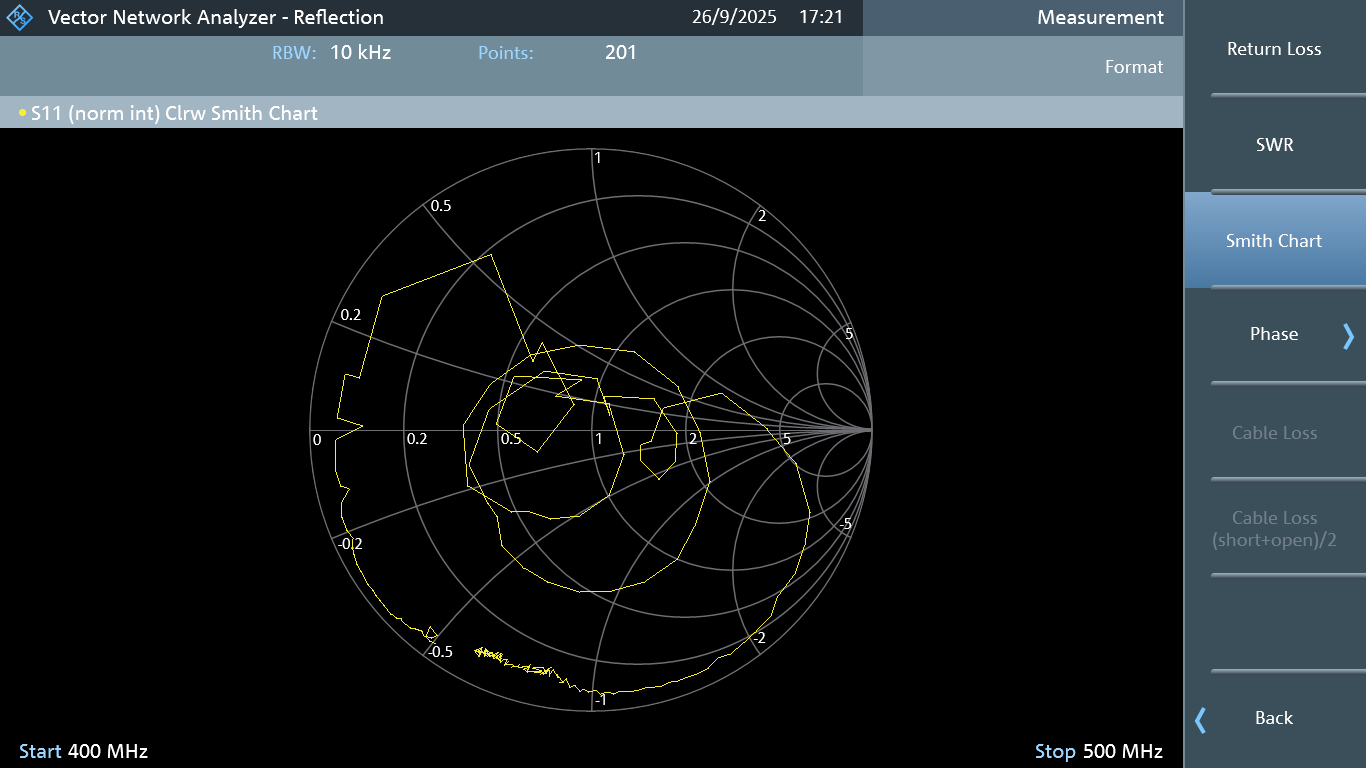

Replay aktualisiert mit screenshot_path: recordings\1-fpc1500_na_s11_replay.json


In [14]:
# Screenshot-Handling:
# - REPLAY=False: Screenshot am Geraet ausloesen, lokal speichern und Replay-Datei damit verknuepfen
# - REPLAY=True : bereits aufgezeichneten Screenshot aus Replay-Datei anzeigen (kein neuer Trigger)

SCREENSHOT_DIR.mkdir(parents=True, exist_ok=True)

if REPLAY:
    replay = load_replay_json(REPLAY_FILE)
    shot_path_str = replay.get('screenshot_path', '')
    shot_path = Path(shot_path_str) if shot_path_str else None

    if shot_path and shot_path.exists():
        print('Replay-Screenshot geladen:', shot_path)
        display(Image(filename=str(shot_path)))
    else:
        print('REPLAY=True: Kein gueltiger screenshot_path in Replay-Datei vorhanden.')
        if shot_path_str:
            print('Gespeicherter Pfad (nicht gefunden):', shot_path_str)
else:
    err = screenshot_save(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME)
    if err:
        print('Screenshot speichern auf dem Geraet fehlgeschlagen:', err)
    else:
        png_bytes = screenshot_read(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME)
        if png_bytes:
            out_path = SCREENSHOT_DIR / f"{REPLAY_FILE.stem.replace('_replay', '')}_screenshot.png"
            out_path.write_bytes(png_bytes)
            print('Gespeichert:', out_path.resolve())
            display(Image(data=png_bytes))

            # Screenshot-Verweis im Replay-JSON ablegen
            try:
                replay = load_replay_json(REPLAY_FILE) if REPLAY_FILE.exists() else {}
                replay['screenshot_path'] = str(out_path)
                save_replay_json(REPLAY_FILE, replay)
                print('Replay aktualisiert mit screenshot_path:', REPLAY_FILE)
            except Exception as ex:
                print('Hinweis: screenshot_path konnte nicht im Replay gespeichert werden:', ex)
        else:
            print('Screenshot konnte nicht gelesen werden.')

In [18]:
import json
import socket
from datetime import datetime
from pathlib import Path

# Interaktive Matplotlib-Widgets (Slider) in Jupyter: ipympl installieren, dann:
#   pip install ipympl
# Ohne ipympl nutzt oft das statische "inline"-Backend — der Slider erscheint, ist aber nicht ziehbar.
try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "widget")
except Exception:
    pass

import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import numpy as np
from IPython.display import Image, display

FPC_IP = "192.168.1.10"
FPC_PORT = 5555
SOCKET_TIMEOUT = 5.0
SCREENSHOT_TIMEOUT = 15.0   # HCOP und Auslesen können deutlich länger als 5 s dauern
TRACE_READ_MAX_BYTES = 2 * 1024 * 1024

# Offline-Workflow: bei REPLAY=True werden Messdaten aus JSON geladen
REPLAY = False
REPLAY_FILE = Path("recordings") / "1-fpc1500_na_s21_replay.json"

SCREENSHOT_DIR = Path("screenshots")
SCREENSHOT_FILENAME = "screen.png"

print(f"Konfiguration: {FPC_IP}:{FPC_PORT}")
print(f"REPLAY={REPLAY}, Datei={REPLAY_FILE}")

Konfiguration: 192.168.1.10:5555
REPLAY=False, Datei=recordings\1-fpc1500_na_s21_replay.json


In [19]:
def scpi_query(host: str, port: int, cmd: str, timeout: float = SOCKET_TIMEOUT, max_bytes: int = 4096) -> str:
    cmd = cmd.strip() + "\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(timeout)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while len(buf) < max_bytes:
            chunk = s.recv(8192)
            if not chunk:
                break
            buf += chunk
            if b"\n" in buf:
                break
        return buf.decode("utf-8", errors="replace").strip()
    finally:
        s.close()

def parse_float_list(raw: str) -> np.ndarray:
    vals = []
    for part in raw.replace(",", " ").split():
        try:
            vals.append(float(part))
        except ValueError:
            continue
    return np.asarray(vals, dtype=np.float64)

def get_freq_axis(host: str, port: int, n: int) -> np.ndarray:
    try:
        f_start = float(scpi_query(host, port, "FREQ:STAR?", max_bytes=256))
        f_stop = float(scpi_query(host, port, "FREQ:STOP?", max_bytes=256))
    except Exception:
        cent = float(scpi_query(host, port, "FREQ:CENT?", max_bytes=256))
        span = float(scpi_query(host, port, "FREQ:SPAN?", max_bytes=256))
        f_start = cent - span / 2.0
        f_stop = cent + span / 2.0
    return np.linspace(f_start, f_stop, n)

def to_s21_db(vals: np.ndarray) -> tuple[np.ndarray, str]:
    if vals.size == 0:
        return vals, "empty"
    vmin = float(np.nanmin(vals))
    vmax = float(np.nanmax(vals))
    looks_like_db = vmax <= 40.0 and vmin < 20.0
    if looks_like_db:
        return vals, "already_dB"
    s21_db = 20.0 * np.log10(np.maximum(np.abs(vals), 1e-12))
    return s21_db, "linear_to_dB"


def save_replay_json(path: Path, data: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2), encoding="utf-8")


def load_replay_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Replay-Datei nicht gefunden: {path}")
    return json.loads(path.read_text(encoding="utf-8"))


def screenshot_save(host: str, port: int, filename: str = "screen.png") -> str | None:
    """Hardcopy auf dem Gerät auslösen und in MMEM speichern. Returns None bei Erfolg, sonst Fehlermeldung."""
    commands = ["HCOP:DEV:LANG PNG", "HCOP:DEST 'MMEM'", f"MMEM:NAME '{filename}'", "HCOP:IMM"]
    cmd = "\n".join(commands) + "\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SCREENSHOT_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while len(buf) < 4096:
            try:
                chunk = s.recv(1024)
                if not chunk:
                    break
                buf += chunk
                if b"\n" in buf:
                    break
            except socket.timeout:
                break
        reply = buf.decode("utf-8", errors="replace").strip()
        if reply and "error" in reply.lower():
            return reply
        return None
    except Exception as e:
        return str(e)
    finally:
        s.close()


def screenshot_read(host: str, port: int, filename: str) -> bytes | None:
    """Datei vom Gerät (MMEM) lesen. MMEM:DATA? Antwort im IEEE 488.2-Blockformat. Returns PNG-Bytes oder None."""
    cmd = f"MMEM:DATA? '{filename}'\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SCREENSHOT_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while b"#" not in buf and len(buf) < 1024:
            chunk = s.recv(256)
            if not chunk:
                return None
            buf += chunk
        if b"#" not in buf:
            return None
        start = buf.index(b"#")
        buf = buf[start:]
        if len(buf) < 2:
            buf += s.recv(2 - len(buf))
        n_digits = int(chr(buf[1]))
        if n_digits < 1 or n_digits > 9:
            return None
        while len(buf) < 2 + n_digits:
            buf += s.recv(2 + n_digits - len(buf))
        data_len = int(buf[2 : 2 + n_digits].decode())
        buf = buf[2 + n_digits :]
        while len(buf) < data_len:
            chunk = s.recv(min(65536, data_len - len(buf)))
            if not chunk:
                break
            buf += chunk
        return buf[:data_len] if len(buf) >= data_len else None
    except Exception:
        return None
    finally:
        s.close()

Gerät: Rohde&Schwarz,FPC1500,1328.6660K03/206021,V1.90
Replay gespeichert: recordings\1-fpc1500_na_s21_replay.json


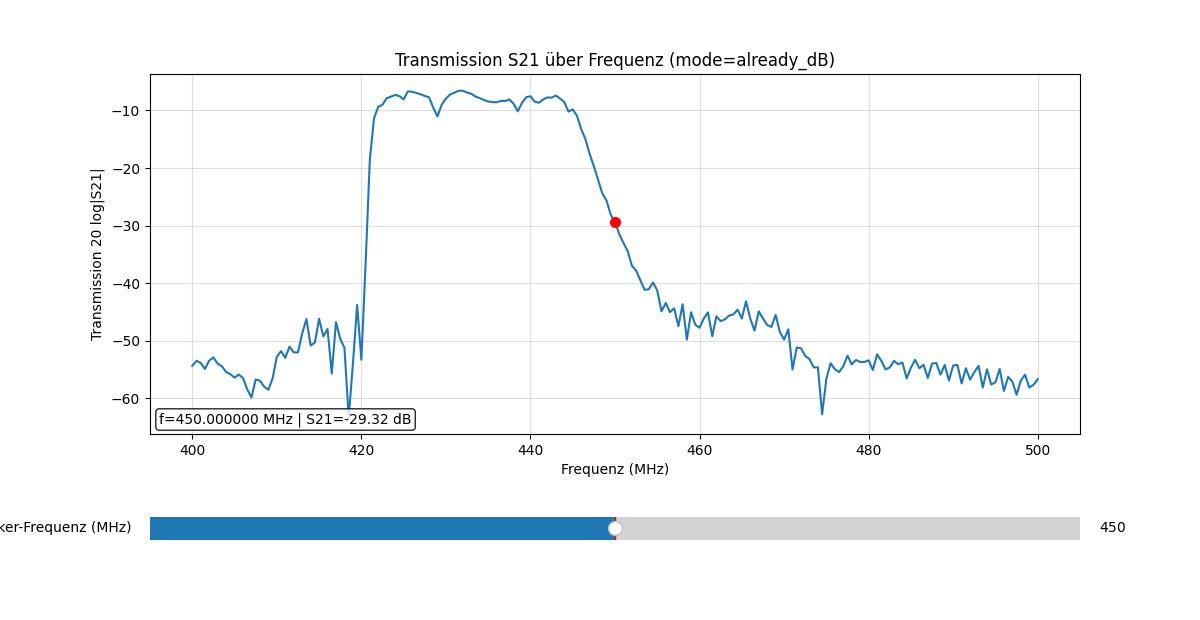

In [20]:
if REPLAY:
    replay = load_replay_json(REPLAY_FILE)
    freq_hz = np.asarray(replay["freq_hz"], dtype=float)
    trace_vals = np.asarray(replay["trace_vals"], dtype=float)
    s21_db = np.asarray(replay["s21_db"], dtype=float)
    s21_mode = replay.get("s21_mode", "replay")
    idn = replay.get("idn", "REPLAY")
    print("Replay geladen:", REPLAY_FILE)
    print("Gerät:", idn)
else:
    idn = scpi_query(FPC_IP, FPC_PORT, "*IDN?")
    print("Gerät:", idn if idn else "Keine Antwort")

    trace_raw = scpi_query(FPC_IP, FPC_PORT, "TRAC:DATA? TRACE1", max_bytes=TRACE_READ_MAX_BYTES)
    trace_vals = parse_float_list(trace_raw)
    if trace_vals.size < 2:
        raise RuntimeError("TRACE1 leer. Bitte S21-Transmission am Gerät einstellen.")

    freq_hz = get_freq_axis(FPC_IP, FPC_PORT, trace_vals.size)
    s21_db, s21_mode = to_s21_db(trace_vals)

    save_replay_json(
        REPLAY_FILE,
        {
            "meta": {"type": "fpc1500_na_s21", "version": 1},
            "idn": idn,
            "s21_mode": s21_mode,
            "freq_hz": freq_hz.tolist(),
            "trace_vals": trace_vals.tolist(),
            "s21_db": s21_db.tolist(),
        },
    )
    print("Replay gespeichert:", REPLAY_FILE)

f_mhz = freq_hz / 1e6

fig = plt.figure(figsize=(12, 6.2))
gs = fig.add_gridspec(2, 1, height_ratios=[1.0, 0.13], hspace=0.35)
ax = fig.add_subplot(gs[0, 0])
ax_slider = fig.add_subplot(gs[1, 0])

ax.plot(f_mhz, s21_db, color="C0", lw=1.5)
ax.set_title(f"Transmission S21 über Frequenz (mode={s21_mode})")
ax.set_xlabel("Frequenz (MHz)")
ax.set_ylabel("Transmission 20 log|S21|")
ax.grid(True, alpha=0.4)

idx0 = int(np.argmin(np.abs(f_mhz - np.mean(f_mhz))))
m_s21, = ax.plot([f_mhz[idx0]], [s21_db[idx0]], "o", color="red", ms=7)
# Text im Haupt-Plot (transAxes), nicht fig.text am unteren Figurenrand — sonst überlappt
# der unsichtbare Kasten die Slider-Achse und blockiert Maus-Events.
info_text = ax.text(
    0.01,
    0.02,
    "",
    transform=ax.transAxes,
    fontsize=10,
    ha="left",
    va="bottom",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.85),
)

slider = Slider(
    ax=ax_slider,
    label="Marker-Frequenz (MHz)",
    valmin=float(f_mhz.min()),
    valmax=float(f_mhz.max()),
    valinit=float(f_mhz[idx0]),
)

def update_marker(f_sel_mhz):
    idx = int(np.argmin(np.abs(f_mhz - f_sel_mhz)))
    m_s21.set_data([f_mhz[idx]], [s21_db[idx]])
    info_text.set_text(f"f={f_mhz[idx]:.6f} MHz | S21={s21_db[idx]:.2f} dB")
    fig.canvas.draw_idle()

slider.on_changed(update_marker)
update_marker(f_mhz[idx0])
plt.show()

Gespeichert: C:\Users\holzi\Desktop\FH\4_Semester\KT\Git\KT-course\lab_suite\labs\08_01_LABOR-9\submissions\screenshots\1-fpc1500_na_s21_screenshot.png


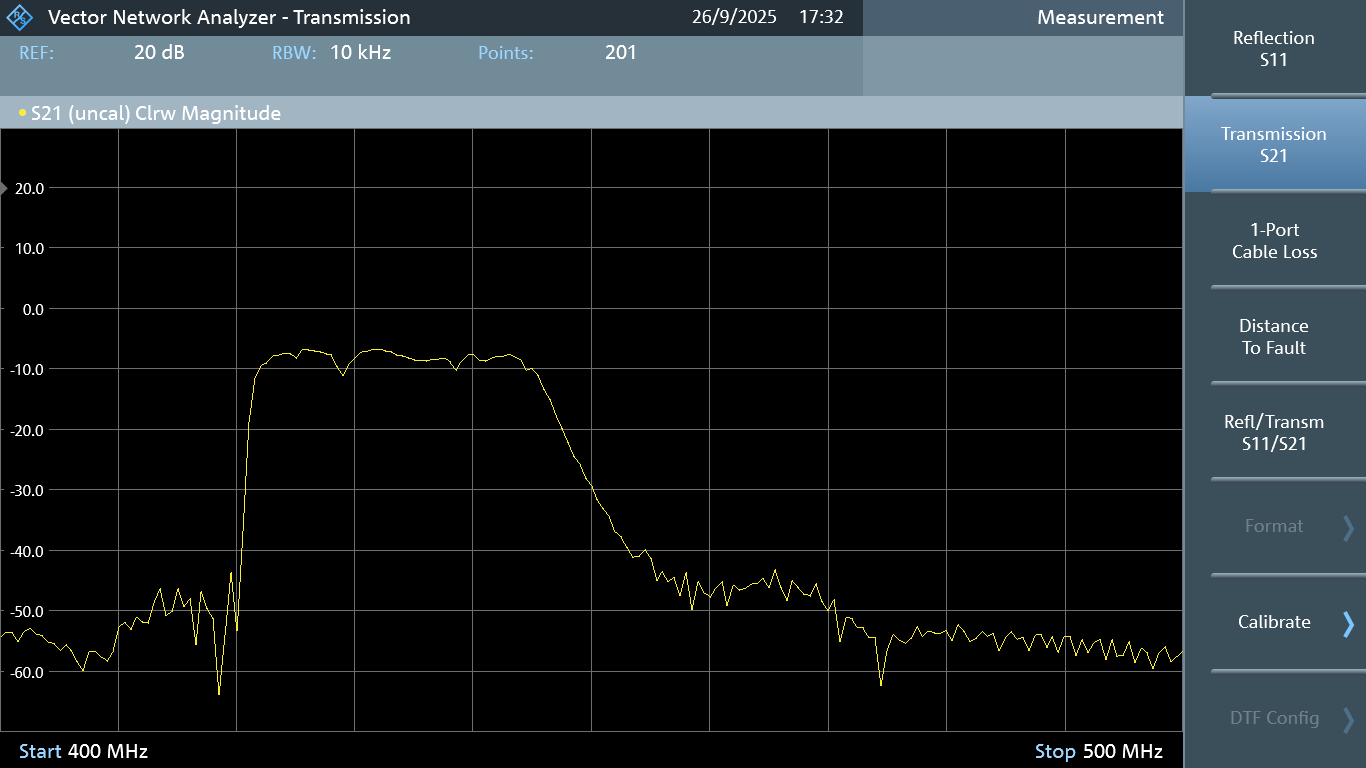

Replay aktualisiert mit screenshot_path: recordings\1-fpc1500_na_s21_replay.json


In [21]:
# Screenshot-Handling:
# - REPLAY=False: Screenshot am Gerät auslösen, lokal speichern und Replay-Datei damit verknüpfen
# - REPLAY=True : bereits aufgezeichneten Screenshot aus Replay-Datei anzeigen (kein neuer Trigger)
# (Am Gerät sollte bei Live-Messung die S21-Transmission sichtbar sein.)

SCREENSHOT_DIR.mkdir(parents=True, exist_ok=True)

if REPLAY:
    replay = load_replay_json(REPLAY_FILE)
    shot_path_str = replay.get('screenshot_path', '')
    shot_path = Path(shot_path_str) if shot_path_str else None

    if shot_path and shot_path.exists():
        print('Replay-Screenshot geladen:', shot_path)
        display(Image(filename=str(shot_path)))
    else:
        print('REPLAY=True: Kein gültiger screenshot_path in Replay-Datei vorhanden.')
        if shot_path_str:
            print('Gespeicherter Pfad (nicht gefunden):', shot_path_str)
else:
    err = screenshot_save(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME)
    if err:
        print('Screenshot speichern auf dem Gerät fehlgeschlagen:', err)
    else:
        png_bytes = screenshot_read(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME)
        if png_bytes:
            out_path = SCREENSHOT_DIR / f"{REPLAY_FILE.stem.replace('_replay', '')}_screenshot.png"
            out_path.write_bytes(png_bytes)
            print('Gespeichert:', out_path.resolve())
            display(Image(data=png_bytes))

            try:
                replay = load_replay_json(REPLAY_FILE) if REPLAY_FILE.exists() else {}
                replay['screenshot_path'] = str(out_path)
                save_replay_json(REPLAY_FILE, replay)
                print('Replay aktualisiert mit screenshot_path:', REPLAY_FILE)
            except Exception as ex:
                print('Hinweis: screenshot_path konnte nicht im Replay gespeichert werden:', ex)
        else:
            print('Screenshot konnte nicht gelesen werden.')